#Test data

#Exploratory data analysis - Before Preprocessing

In [ ]:
#import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load the dataset
test_df = pd.read_csv('test.csv')

In [ ]:
#Display basic information
test_df.head()

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales
0,33574,batticaloa,2686.5,3582,12537
1,10089,batticaloa,1717.56,2576.34,9446.58
2,38329,batticaloa,854.04,1242.24,5201.88
3,11376,batticaloa,1638.12,2320.67,9282.68
4,12410,batticaloa,1039.09,1518.67,5435.24


In [ ]:
#check number of observations and columns
test_df.shape

(40749, 5)

In [ ]:
#Check data types
test_df.dtypes

,0
Customer_ID,int64
outlet_city,object
luxury_sales,object
fresh_sales,object
dry_sales,object


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40749 entries, 0 to 40748
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Customer_ID   40749 non-null  int64 
 1   outlet_city   40749 non-null  object
 2   luxury_sales  40749 non-null  object
 3   fresh_sales   40749 non-null  object
 4   dry_sales     40749 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.6+ MB


In [ ]:
#Descriptive statistics
test_df.describe(include = 'all')

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales
count,40749.000000,40749,40749,40749,40749
unique,NaN,27,33183,36100,35771
top,NaN,Jaffna,1801.8,6606.87,1327.2
freq,NaN,2226,7,5,5
mean,20375.000000,NaN,NaN,NaN,NaN
std,11763.367396,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN
25%,10188.000000,NaN,NaN,NaN,NaN
50%,20375.000000,NaN,NaN,NaN,NaN
75%,30562.000000,NaN,NaN,NaN,NaN


In [ ]:
#check missing values
test_df.isnull().sum()

,0
Customer_ID,0
outlet_city,0
luxury_sales,0
fresh_sales,0
dry_sales,0


In [ ]:
#Finding duplicate values
test_df.duplicated().sum()

0

In [ ]:
#finding unique values in outlet_city in Test data
unique_outlet_city = test_df['outlet_city'].unique()
length_Test = len(unique_outlet_city)
print(unique_outlet_city)
length_Test

['batticaloa' 'Batticaloa' 'Colombo' 'Dehiwala-Mount Lavinia'
 'Anuradhapura' 'Galle' 'Gampaha' 'Homagama' 'Jaffna' 'Kaduwela'
 'Kalmunai' 'kalmunai' 'Kandy' 'Katunayake' 'Kelaniya' 'Madawachiya'
 'Kotte' 'Moratuwa' 'MoraTuwa' 'Negombo' 'Nuwara Eliya' 'Panadura'
 'Peliyagoda' 'PeliyagodA' 'Trincomale' 'Trincomalee' 'Wattala']


27

#Univariate analysis - Before preprocessing

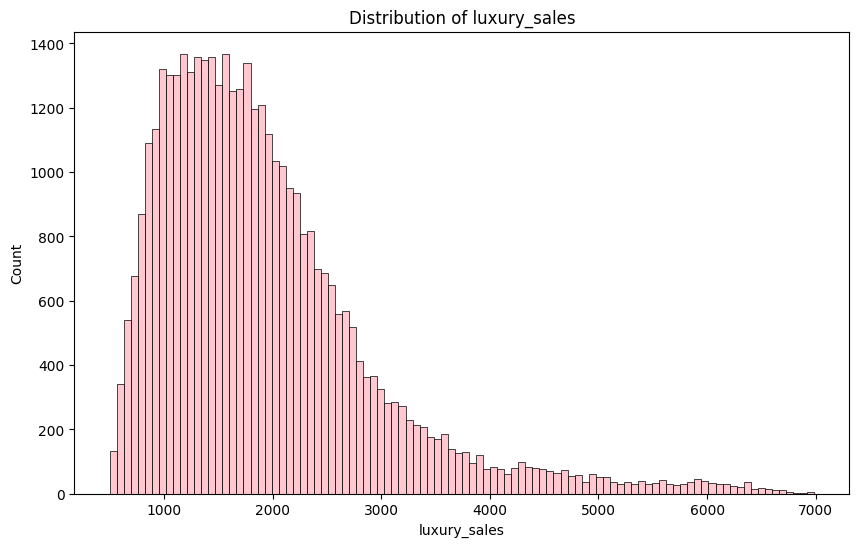

In [ ]:
#Finding distribution of luxury sales
test_df['luxury_sales'] = pd.to_numeric(test_df['luxury_sales'], errors = 'coerce')

plt.figure(figsize=(10,6))
sns.histplot(test_df['luxury_sales'], color='lightpink')
plt.title('Distribution of luxury_sales')
plt.show()

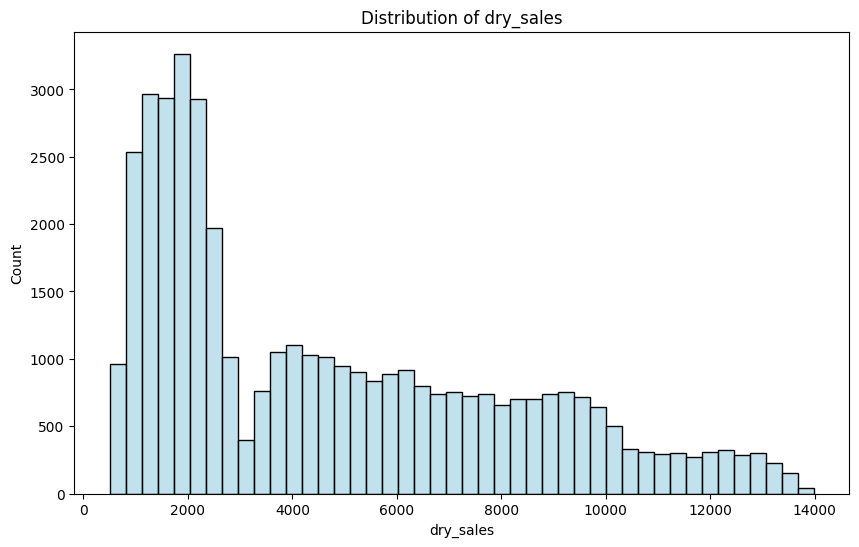

In [ ]:
#Finding distribution of dry sales
test_df['dry_sales'] = pd.to_numeric(test_df['dry_sales'], errors = 'coerce')

plt.figure(figsize=(10,6))
sns.histplot(test_df['dry_sales'], color='lightblue')
plt.title('Distribution of dry_sales')
plt.show()

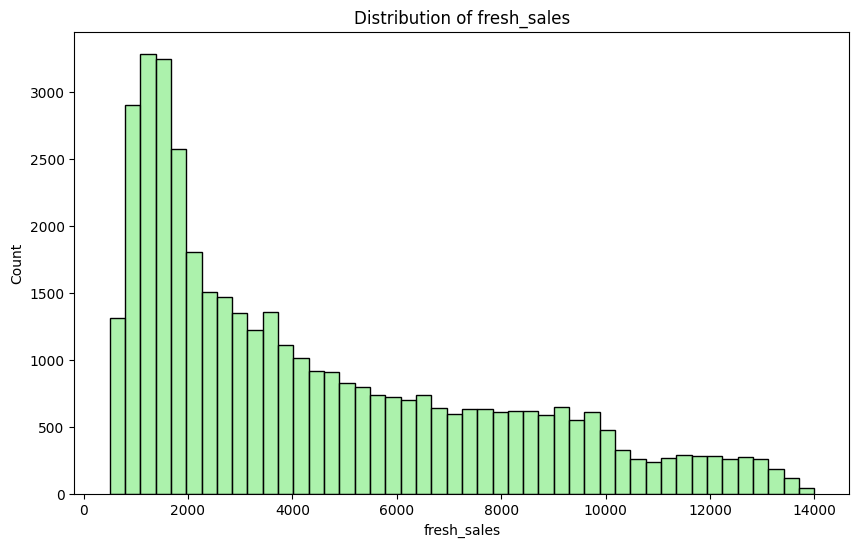

In [ ]:
#Finding distribution of fresh sales
test_df['fresh_sales'] = pd.to_numeric(test_df['fresh_sales'], errors = 'coerce')

plt.figure(figsize=(10,6))
sns.histplot(test_df['fresh_sales'], color='lightgreen')
plt.title('Distribution of fresh_sales')
plt.show()

#Multivariate analysis - Before preprocessing

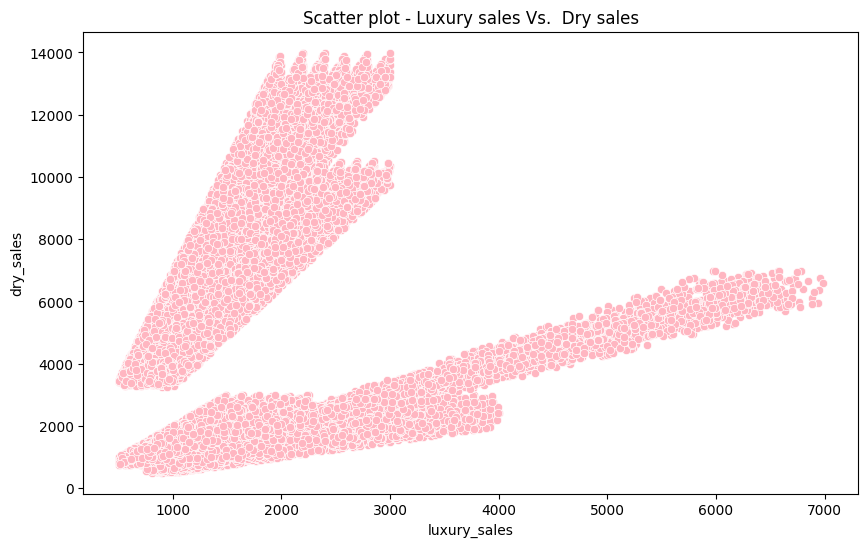

In [ ]:
#Scatter plot - Luxury sales Vs. Dry sales
plt.figure(figsize=(10,6))
sns.scatterplot(x='luxury_sales', y='dry_sales', data=test_df, color='lightpink')
plt.title('Scatter plot - Luxury sales Vs.  Dry sales')
plt.show()

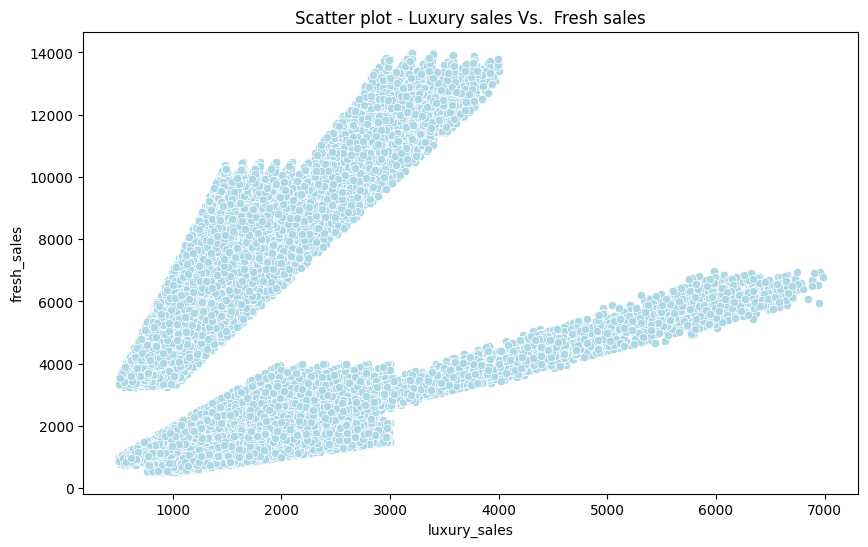

In [ ]:
#Scatter plot - Luxury sales Vs. Fresh sales
plt.figure(figsize=(10,6))
sns.scatterplot(x='luxury_sales', y='fresh_sales', data=test_df, color='lightblue')
plt.title('Scatter plot - Luxury sales Vs.  Fresh sales')
plt.show()

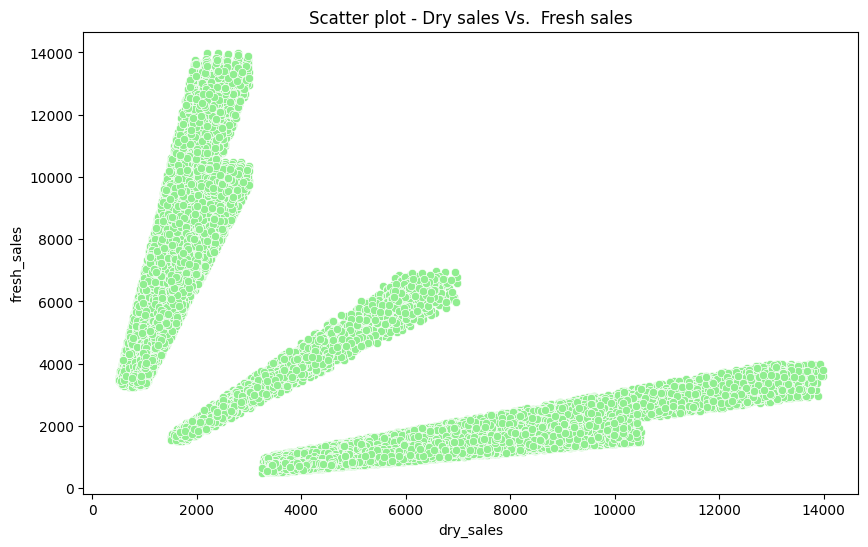

In [ ]:
#Scatter plot - Dry sales Vs. Fresh sales
plt.figure(figsize=(10,6))
sns.scatterplot(x='dry_sales', y='fresh_sales', data=test_df, color='lightgreen')
plt.title('Scatter plot - Dry sales Vs.  Fresh sales')
plt.show()

Text(0.5, 1.0, 'Luxury sales Vs. Outlet city')

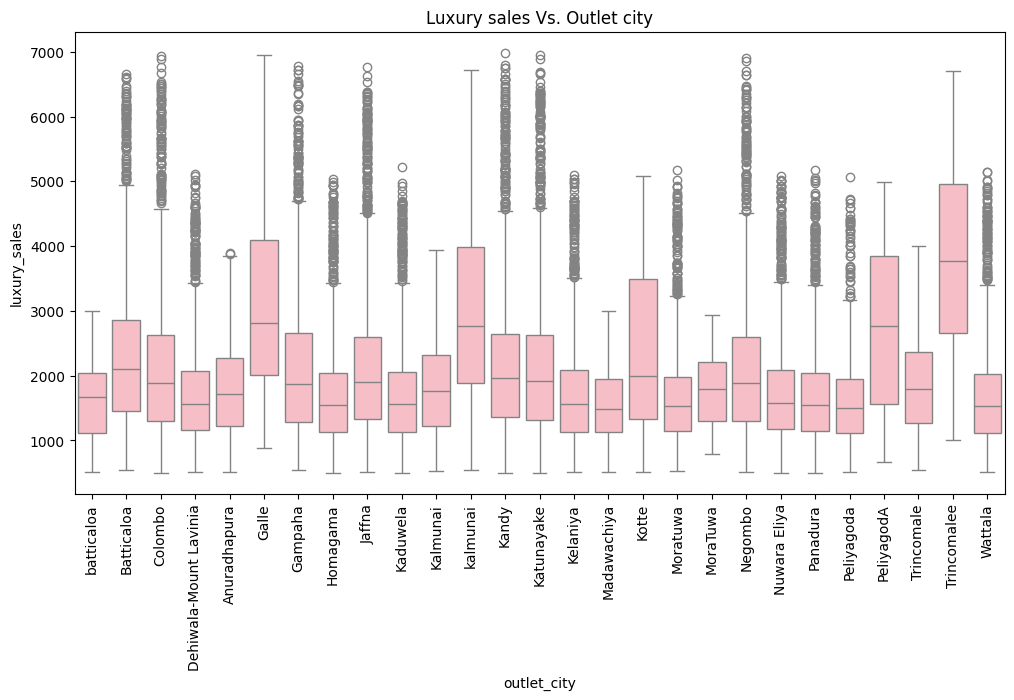

In [ ]:
#Luxury sales Vs. Outlet city
plt.figure(figsize=(12,6))
sns.boxplot(x='outlet_city', y='luxury_sales', data=test_df, color='lightpink')
plt.xticks(rotation=90)
plt.title('Luxury sales Vs. Outlet city')

Text(0.5, 1.0, 'Dry sales Vs. Outlet city')

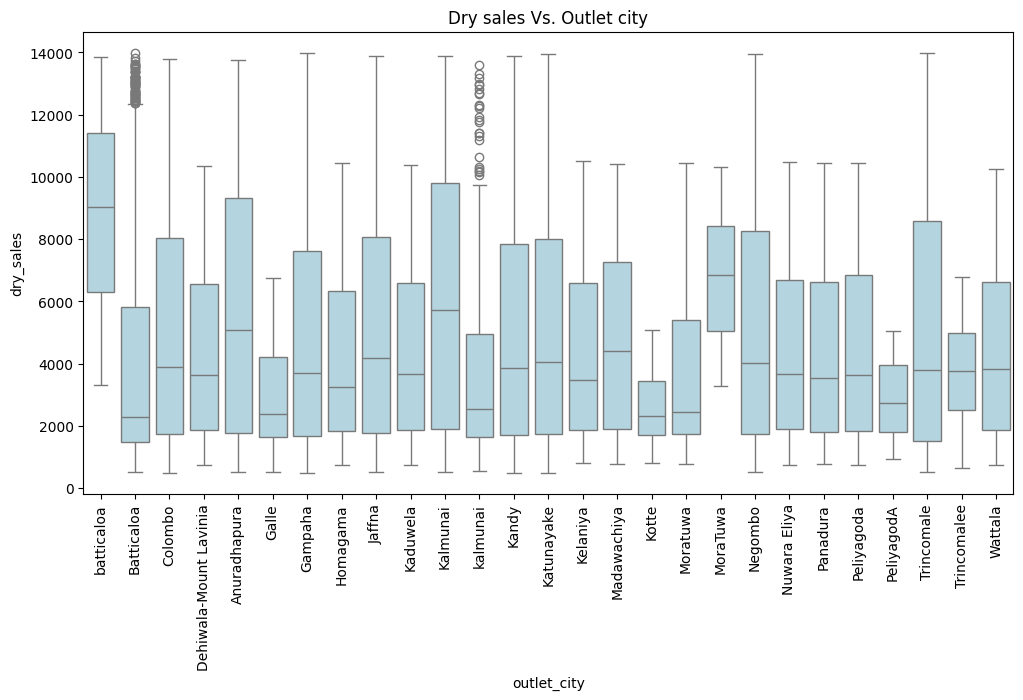

In [ ]:
#Dry sales Vs. Outlet city
plt.figure(figsize=(12,6))
sns.boxplot(x='outlet_city', y='dry_sales', data=test_df, color='lightblue')
plt.xticks(rotation=90)
plt.title('Dry sales Vs. Outlet city')

Text(0.5, 1.0, 'Fresh sales Vs. Outlet city')

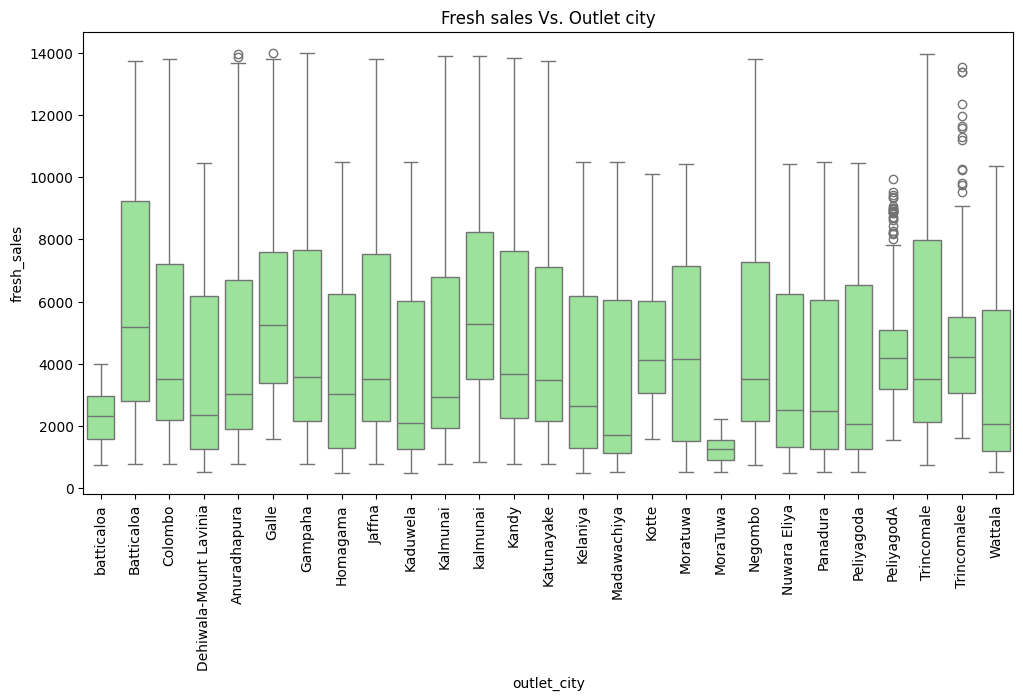

In [ ]:
#Fresh sales Vs. Outlet city
plt.figure(figsize=(12,6))
sns.boxplot(x='outlet_city', y='fresh_sales', data=test_df, color='lightgreen')
plt.xticks(rotation=90)
plt.title('Fresh sales Vs. Outlet city')

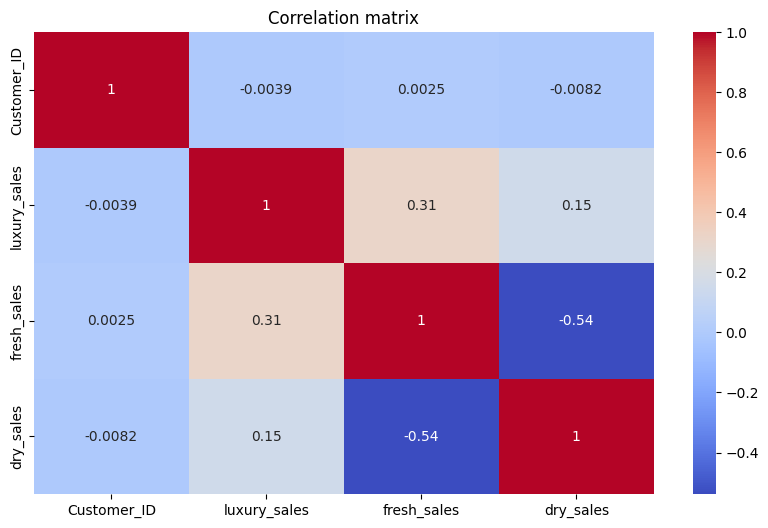

In [ ]:
#correlation matrix
corr_matrix = test_df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

#Data Preprocessing

In [ ]:
#Change the data types to numeric
test_df['luxury_sales'] = pd.to_numeric(test_df['luxury_sales'], errors = 'coerce')
test_df['dry_sales'] = pd.to_numeric(test_df['dry_sales'], errors = 'coerce')
test_df['fresh_sales'] = pd.to_numeric(test_df['fresh_sales'], errors = 'coerce')

In [ ]:
#Check for missing values
test_df.isnull().sum()

,0
Customer_ID,0
outlet_city,0
luxury_sales,2
fresh_sales,1
dry_sales,1


In [ ]:
#Find the rows that have missing values
missing_rows = test_df[test_df.isnull().any(axis=1)]
missing_rows

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales
6,10364,batticaloa,NaN,914.40,3352.80
6299,4059,Anuradhapura,NaN,1548.69,5705.70
13949,28662,Jaffna,2195.84,NaN,1509.64
40746,28664,Wattala,3838.60,3951.50,NaN


In [ ]:
test_check = pd.read_csv('test.csv')
test_check[test_check['Customer_ID'].isin([10364,4059,28662,28664])]

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales
6,10364,batticaloa,Seven Hundread and sixty Ruppees,914.4,3352.8
6299,4059,Anuradhapura,Eight Hundread and fifteen ruppes,1548.69,5705.7
13949,28662,Jaffna,2195.84,Nine thousand ruppess,1509.64
40746,28664,Wattala,3838.6,3951.5,Three Thousand seven hundread ruppees


In [31]:
#convert textual figures into numbers
test_df.loc[test_df['Customer_ID']== 10364, 'luxury_sales'] = 760
test_df.loc[test_df['Customer_ID']== 4059, 'luxury_sales'] = 815
test_df.loc[test_df['Customer_ID']== 28662, 'fresh_sales'] = 9000
test_df.loc[test_df['Customer_ID']== 28664, 'dry_sales'] = 3700

In [32]:
#Check for missing values after cleaning
test_df.isnull().sum()

,0
Customer_ID,0
outlet_city,0
luxury_sales,0
fresh_sales,0
dry_sales,0


In [34]:
#change Customer_ID to object data type
test_df['Customer_ID'] = test_df['Customer_ID'].astype(str)
test_df.dtypes

,0
Customer_ID,object
outlet_city,object
luxury_sales,float64
fresh_sales,float64
dry_sales,float64


In [36]:
#finding unique values
#outlet_city
unique_outlet_city = test_df['outlet_city'].unique()
length_Test = len(unique_outlet_city)

# Print the length of unique outlet cities
print(f"Number of unique outlet cities: {length_Test}")
print(f"Unique outlet_city: {unique_outlet_city}")

Number of unique outlet cities: 27
Unique outlet_city: ['batticaloa' 'Batticaloa' 'Colombo' 'Dehiwala-Mount Lavinia'
 'Anuradhapura' 'Galle' 'Gampaha' 'Homagama' 'Jaffna' 'Kaduwela'
 'Kalmunai' 'kalmunai' 'Kandy' 'Katunayake' 'Kelaniya' 'Madawachiya'
 'Kotte' 'Moratuwa' 'MoraTuwa' 'Negombo' 'Nuwara Eliya' 'Panadura'
 'Peliyagoda' 'PeliyagodA' 'Trincomale' 'Trincomalee' 'Wattala']


In [39]:
city_corrections = {
    'PeliyagodA':'Peliyagoda',
    'Madawachiya':'Medawachchiya',
    'batticaloa':'Batticaloa',
    'kalmunai' : 'Kalmunai',
    'Trincomale':'Trincomalee',
    'MoraTuwa':'Moratuwa'

}

test_df['outlet_city'] = test_df['outlet_city'].replace(city_corrections)

In [40]:
#finding unique values
#outlet_city
unique_outlet_city = test_df['outlet_city'].unique()
length_Test = len(unique_outlet_city)

# Print the length of unique outlet cities
print(f"Number of unique outlet cities: {length_Test}")
print(f"Unique outlet_city: {unique_outlet_city}")

Number of unique outlet cities: 22
Unique outlet_city: ['Batticaloa' 'Colombo' 'Dehiwala-Mount Lavinia' 'Anuradhapura' 'Galle'
 'Gampaha' 'Homagama' 'Jaffna' 'Kaduwela' 'Kalmunai' 'Kandy' 'Katunayake'
 'Kelaniya' 'Medawachchiya' 'Kotte' 'Moratuwa' 'Negombo' 'Nuwara Eliya'
 'Panadura' 'Peliyagoda' 'Trincomalee' 'Wattala']


<Axes: xlabel='luxury_sales'>

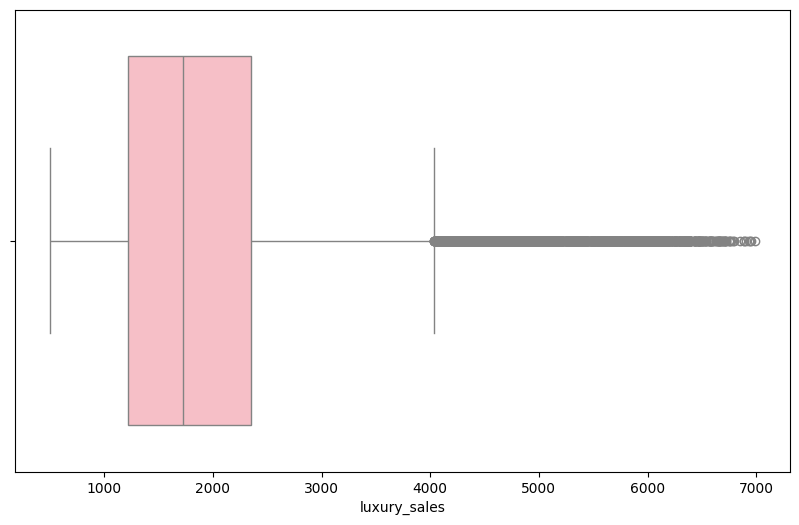

In [47]:
#box plot for luxury sales
plt.figure(figsize=(10,6))
sns.boxplot(x='luxury_sales', data=test_df, color='lightpink')

<Axes: xlabel='dry_sales'>

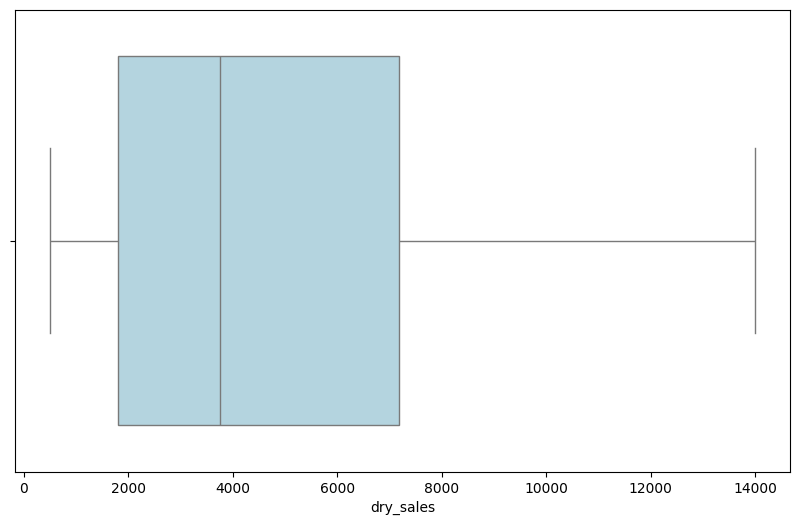

In [48]:
#box plot for dry sales
plt.figure(figsize=(10,6))
sns.boxplot(x='dry_sales', data=test_df, color='lightblue')

<Axes: xlabel='fresh_sales'>

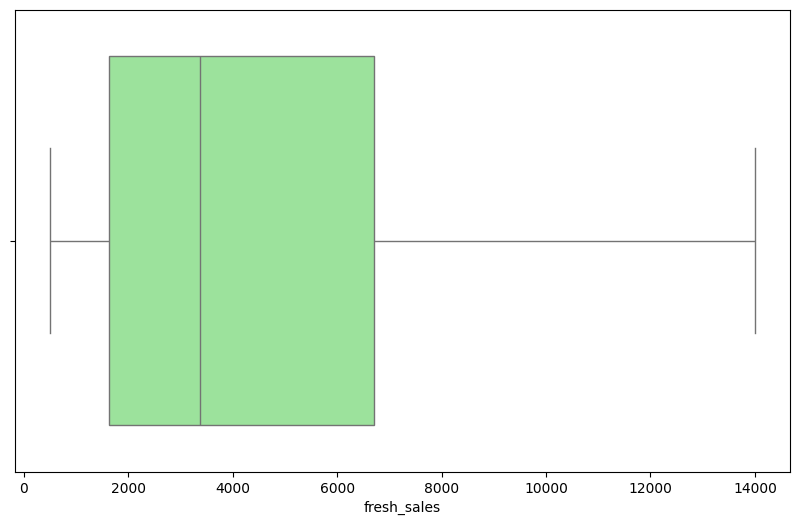

In [49]:
#box plot for fresh sales
plt.figure(figsize=(10,6))
sns.boxplot(x='fresh_sales', data=test_df, color='lightgreen')

In [50]:
#Encoding outlet_city so that it is considered as a numeric variable
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
test_df['outlet_city'] = test_df['outlet_city'].astype('category')
test_df['outlet_city_encoded'] = test_df['outlet_city'].cat.codes
test_df.head()

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,outlet_city_encoded
0,33574,Batticaloa,2686.50,3582.00,12537.00,1
1,10089,Batticaloa,1717.56,2576.34,9446.58,1
2,38329,Batticaloa,854.04,1242.24,5201.88,1
3,11376,Batticaloa,1638.12,2320.67,9282.68,1
4,12410,Batticaloa,1039.09,1518.67,5435.24,1


#Exploratory Data Analysis - After Preprocessing

#Univariate Analysis - After Preprocessing

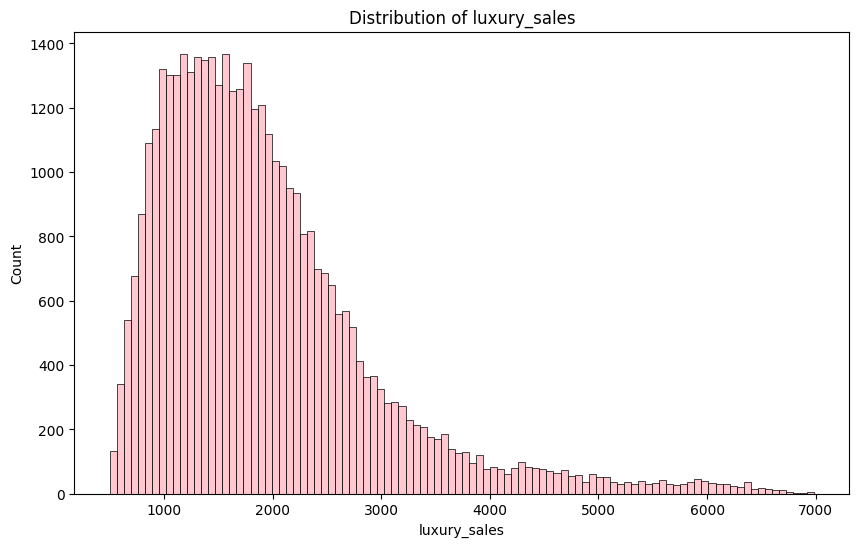

In [51]:
#distribution of luxury sales
plt.figure(figsize=(10,6))
sns.histplot(test_df['luxury_sales'], color='lightpink')
plt.title('Distribution of luxury_sales')
plt.show()

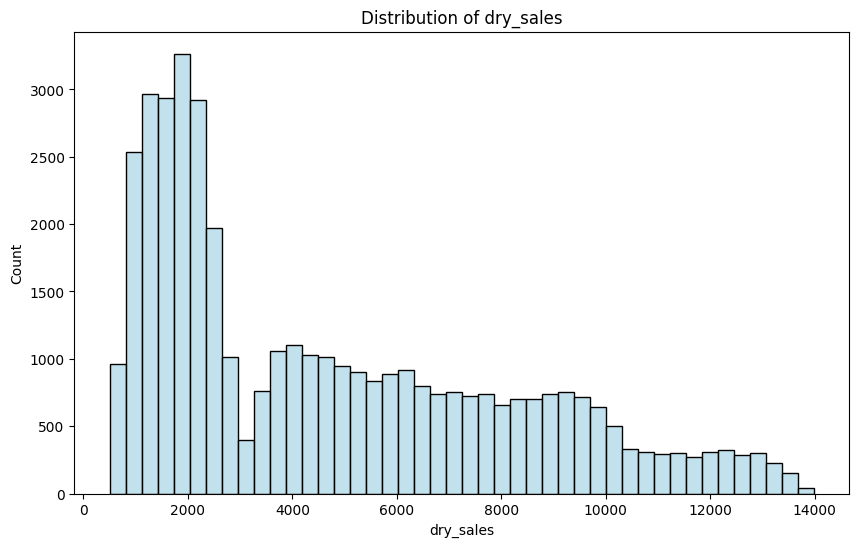

In [52]:
#distribution of dry sales
plt.figure(figsize=(10,6))
sns.histplot(test_df['dry_sales'], color='lightblue')
plt.title('Distribution of dry_sales')
plt.show()

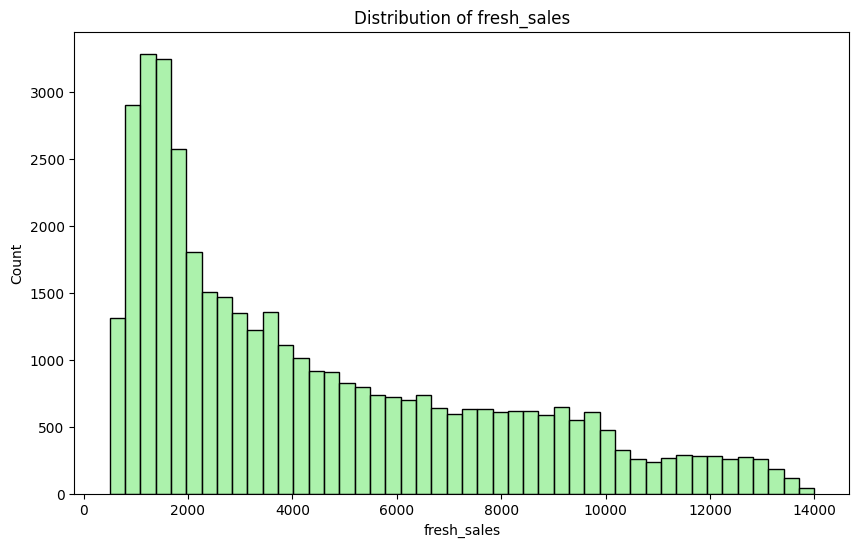

In [53]:
#distribution of fresh sales
plt.figure(figsize=(10,6))
sns.histplot(test_df['fresh_sales'], color='lightgreen')
plt.title('Distribution of fresh_sales')
plt.show()

#Multi-Variate Analysis - After Preprocessing

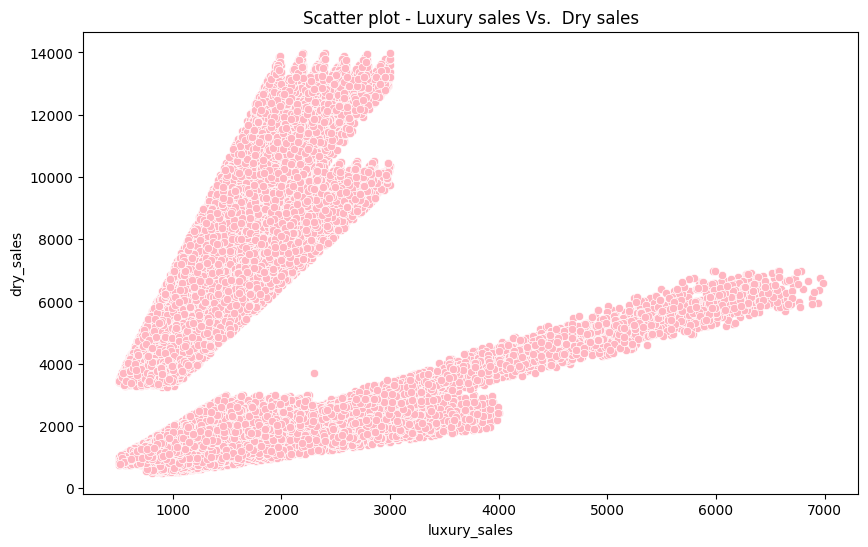

In [54]:
#Scatter plot for Luxury Sales Vs. Dry sales
plt.figure(figsize=(10,6))
sns.scatterplot(x='luxury_sales', y='dry_sales', data=test_df, color='lightpink')
plt.title('Scatter plot - Luxury sales Vs.  Dry sales')
plt.show()

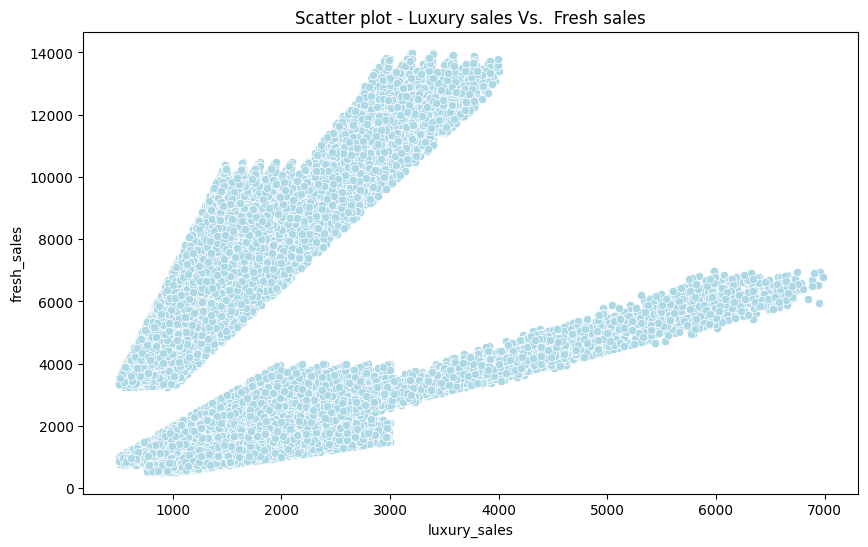

In [55]:
#Scatter plot for Luxury sales Vs Fresh sales
plt.figure(figsize=(10,6))
sns.scatterplot(x='luxury_sales', y='fresh_sales', data=test_df, color='lightblue')
plt.title('Scatter plot - Luxury sales Vs.  Fresh sales')
plt.show()

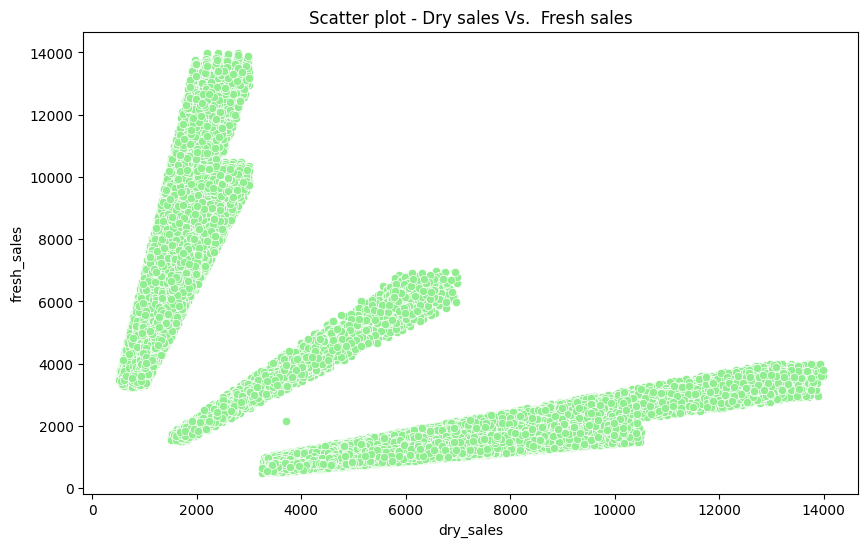

In [56]:
#Scatter plot for dry sales Vs fresh sales
plt.figure(figsize=(10,6))
sns.scatterplot(x='dry_sales', y='fresh_sales', data=test_df, color='lightgreen')
plt.title('Scatter plot - Dry sales Vs.  Fresh sales')
plt.show()

Text(0.5, 1.0, 'Luxury sales Vs. Outlet city')

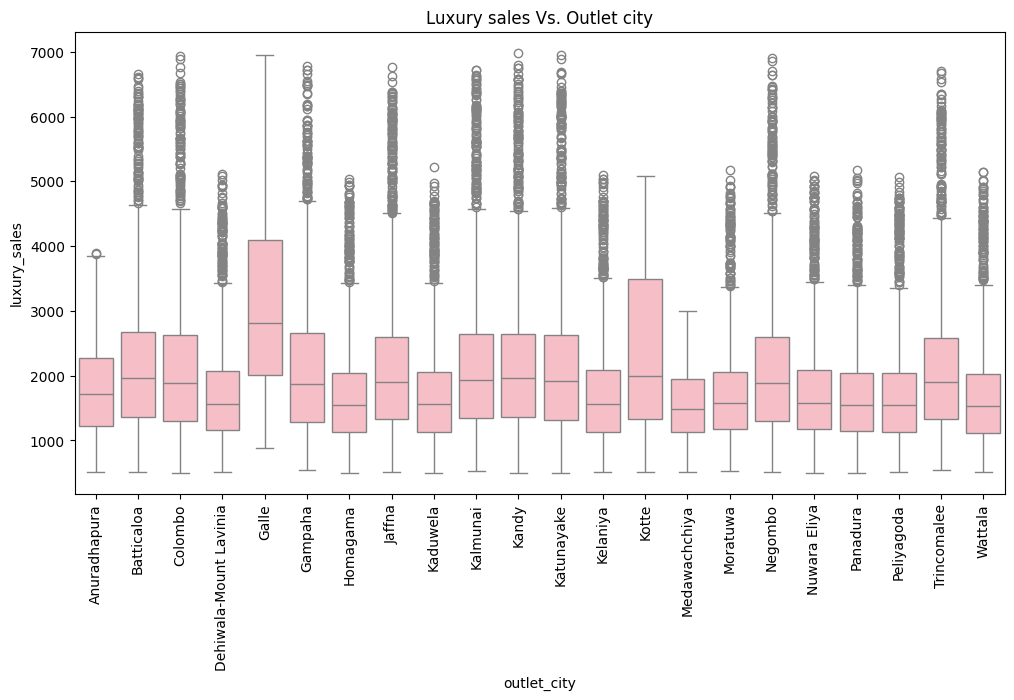

In [57]:
#Luxury sales Vs. Outlet city
plt.figure(figsize=(12,6))
sns.boxplot(x='outlet_city', y='luxury_sales', data=test_df, color='lightpink')
plt.xticks(rotation=90)
plt.title('Luxury sales Vs. Outlet city')

Text(0.5, 1.0, 'Dry sales Vs. Outlet city')

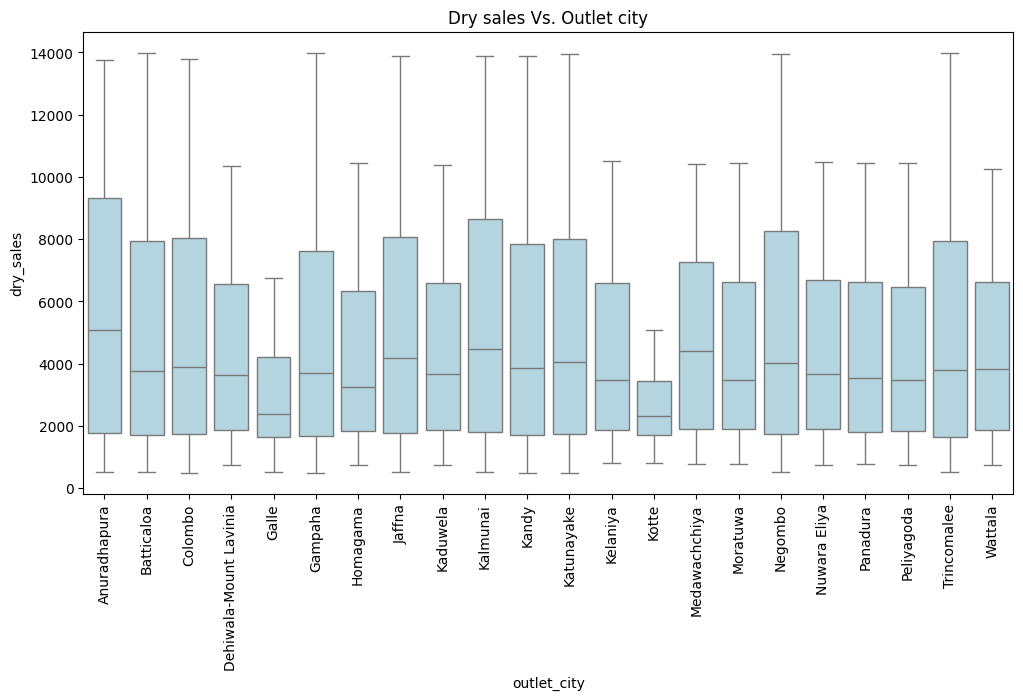

In [58]:
#Dry sales Vs. Outlet city
plt.figure(figsize=(12,6))
sns.boxplot(x='outlet_city', y='dry_sales', data=test_df, color='lightblue')
plt.xticks(rotation=90)
plt.title('Dry sales Vs. Outlet city')

Text(0.5, 1.0, 'Fresh sales Vs. Outlet city')

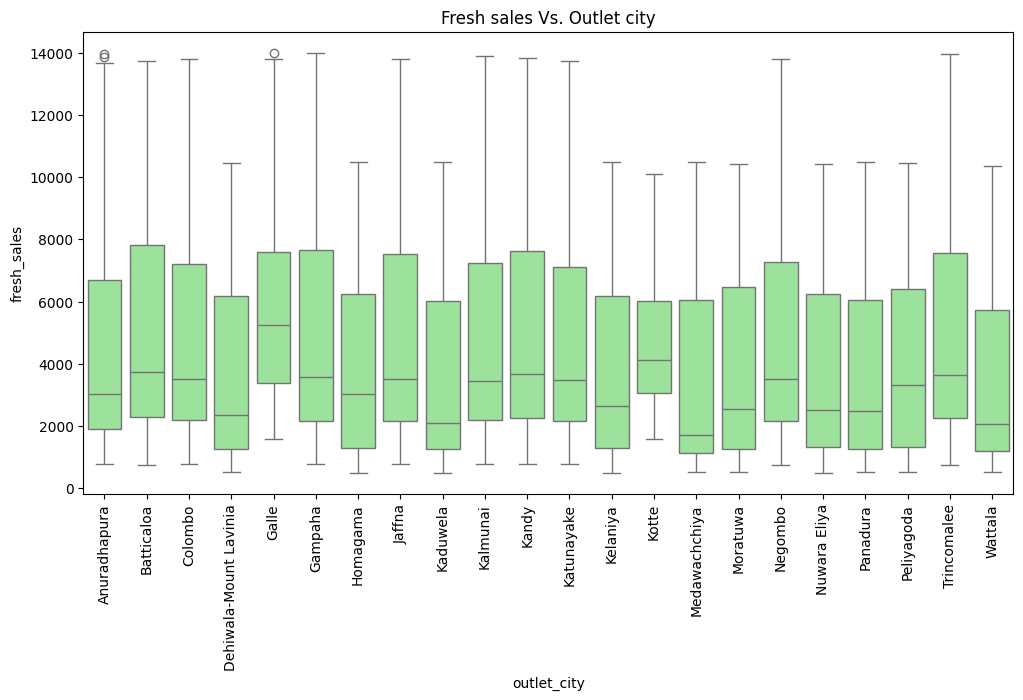

In [60]:
#Fresh sales Vs. Outlet city
plt.figure(figsize=(12,6))
sns.boxplot(x='outlet_city', y='fresh_sales', data=test_df, color='lightgreen')
plt.xticks(rotation=90)
plt.title('Fresh sales Vs. Outlet city')

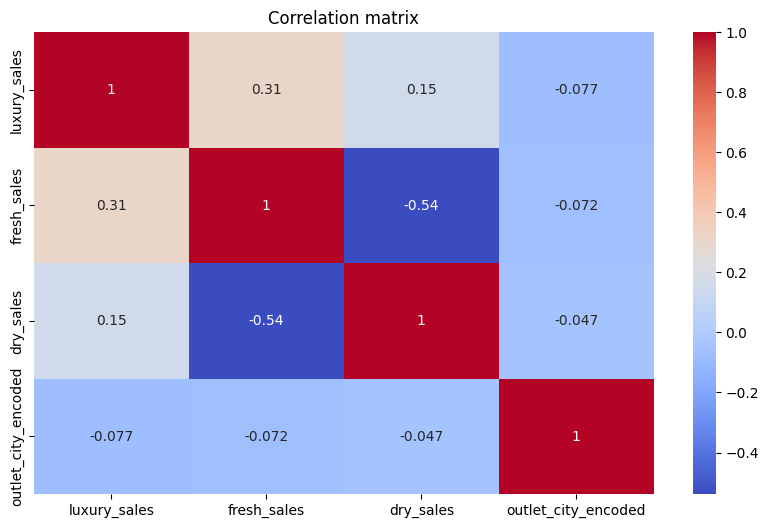

In [61]:
#correlation matrix
corr_matrix = test_df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()